In [161]:
import torch
import time
import imageio
import numpy as np
import pandas as pd 
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from IPython.display import clear_output

ODE Solver

In [162]:
def euler_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim])
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0

    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        y = y + func(t[i - 1], y) * dt
        ys.append(y)

    return torch.stack(ys, dim=0)  # shape: [T, batch, dim]

In [163]:
def improved_euler_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = y + k1 * dt
        y = y + (k1 + func(t[i], k2)) * dt / 2
        ys.append(y)
    return torch.stack(ys, dim=0)


In [164]:
def rk2_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
        y = y + k2 * dt
        ys.append(y)
    return torch.stack(ys, dim=0)

In [165]:
def rk4_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
        k3 = func(t[i-1] + dt/2, y + k2 * dt / 2)
        k4 = func(t[i-1] + dt, y + k3 * dt)
        y = y + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        ys.append(y)
    return torch.stack(ys, dim=0)

Neural ODE

In [166]:
class ODEFunc(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(4, 20),
                             nn.Tanh(),
                             nn.Linear(20, 4))
    for m in self.net.modules():
      if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.1)
        nn.init.constant_(m.bias, val=0)

  def forward(self, t, y):
    output = self.net(y)
    return output

Load Data

In [167]:
# Load simulation data
data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/USETHIS_Simulation_output.csv')

# Convert data to numpy arrays
t_np = data['time'].values.astype(np.float32)
C1_np = data['CENT'].values.astype(np.float32)
C2_np = data['PERIPH'].values.astype(np.float32)
C3_np = data['PERIPH2'].values.astype(np.float32)
C4_np = data['CP'].values.astype(np.float32)

# Verify shapes of the arrays
print(t_np.shape, C1_np.shape, C2_np.shape, C3_np.shape, C4_np.shape)

(97,) (97,) (97,) (97,) (97,)


In [168]:
# Convert numpy arrays to PyTorch tensors
t = torch.tensor(t_np, dtype=torch.float32)
C1 = torch.tensor(C1_np, dtype=torch.float32)
C2 = torch.tensor(C2_np, dtype=torch.float32)
C3 = torch.tensor(C3_np, dtype=torch.float32)
C4 = torch.tensor(C4_np, dtype=torch.float32)
print(C1.shape, C2.shape, C3.shape, C4.shape)

# Store data in a single tensor and compute mean and std
C_temp = torch.stack([C1, C2, C3, C4], dim=1) 
mu = C_temp.mean(dim=0, keepdim=True) 
sigma = C_temp.std(dim=0, keepdim=True)

# Normalize each concentration variable
C1 = (C1 - C1.mean()) / C1.std()
C2 = (C2 - C2.mean()) / C2.std()
C3 = (C3 - C3.mean()) / C3.std()
C4 = (C4 - C4.mean()) / C3.std()

# Combine normalized concentrations into a single tensor
C_all = torch.stack([C1, C2, C3, C4], dim=1)
C_all = C_all.unsqueeze(1)
print(C_all.shape)

torch.Size([97]) torch.Size([97]) torch.Size([97]) torch.Size([97])
torch.Size([97, 1, 4])


In [169]:
# Prepare training data
data_size = C_all.shape[0]
batch_time = 96
batch_size = 1
C_0 = C_all[0, 0, :].unsqueeze(0)  # (batch_size, 1, emb)
print(C_0.shape)
print(C_all.shape)

def get_batch():
  s = torch.from_numpy(np.random.choice(np.arange(data_size - batch_time, dtype=np.int64), batch_size, replace=False))
  batch_c0 = C_all[s]  # (batch_size, 1, emb)
  batch_t = t[:batch_time]  # (T)
  batch_c = torch.stack([C_all[s + i] for i in range(batch_time)], dim=0)  # (time, batch_size, 1, emb)
  return batch_c0, batch_t, batch_c

torch.Size([1, 4])
torch.Size([97, 1, 4])


In [170]:
def visualize(C_all, pred_c, mu, sigma):
    pred_c = pred_c.squeeze(1)  # shape: [time, 4]
    C_all = C_all.squeeze(1)  # shape: [time, 4]

    C_all_orig = C_all * sigma + mu
    pred_c_orig = pred_c * sigma + mu

    # Plot each concentration
    fig = plt.figure(figsize=(10, 6)) 
    colors = ['blue', 'orange', 'green', 'red']
    compartment = ['Central', 'Peripheral 1', 'Peripheral 2', 'CP']

    for i in range(4):
        plt.scatter(t, C_all_orig[:, i], color=colors[i], marker='o', label=f'True {compartment[i]} Compt', s=20)
        plt.plot(t, pred_c_orig[:, i], linestyle='--', color=colors[i], label=f'Pred {compartment[i]} Compt')

    plt.xlabel('Time')
    plt.ylabel('Concentration')
    plt.title('True vs Predicted Concentrations')
    plt.legend()
    plt.grid(True)
    plt.show()
    return fig

In [171]:
def plot_loss(loss_history):
        plt.figure(figsize=(10, 6))
        plt.plot(loss_history, '-', markersize=3)
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss Over Time")
        plt.grid(True)
        plt.show()

In [172]:
def train_NODE(C_0, t, C_all, mu, sigma, solver, niters=400, method='dopri8', gif=False):
    func = ODEFunc()
    optimizer = optim.RMSprop(func.parameters(), lr=1e-3)
    loss_history = []

    # Only create frame storage if gif=True
    frames = [] if gif else None

    start_time = time.time()

    for iter in range(niters + 1):
        optimizer.zero_grad()
        batch_c0, batch_t, batch_c = get_batch()

        #pred_C = odeint(func = func, c0=batch_c0, t=batch_t, rtol=1e-7, atol=1e-9, method=method)
        pred_C = solver(func, batch_c0, batch_t)
        
        loss = torch.mean(torch.abs(pred_C - batch_c))
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if iter % 50 == 0:
            with torch.no_grad():
                clear_output(wait=True)

                #pred_C = odeint(func, C_0, t, rtol=1e-7, atol=1e-9, method=method)
                pred_C = solver(func, C_0, t)

                loss = torch.mean(torch.abs(pred_C - C_all))
                print(f"Iter {iter:04d} | Total Loss {loss.item():.6f}")

                # always show visualization
                fig = visualize(C_all, pred_C, mu, sigma)

                # Only save frames if gif=True
                if gif:
                    fig.canvas.draw()
                    buf = fig.canvas.buffer_rgba()
                    image = np.asarray(buf, dtype=np.uint8)
                    frames.append(image)
                plt.close(fig)

    plot_loss(loss_history)

    # Save GIF only when user requests it
    if gif:
        imageio.mimsave(f"../../images/training_animation_{solver}.gif", frames, fps=3)
        print("Saved GIF: training_animation.gif")

    print(f"Process time: {time.time() - start_time:.2f} sec")


Iter 0400 | Total Loss 0.084184


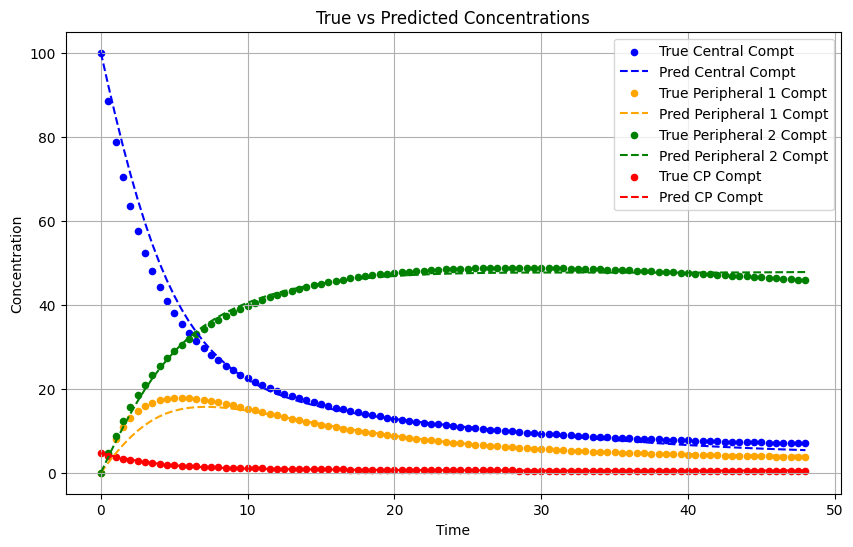

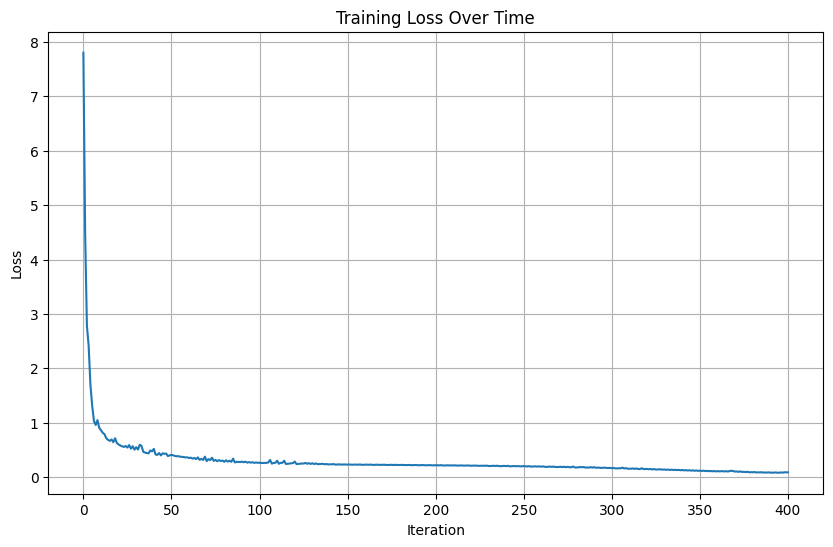

Saved GIF: training_animation.gif
Process time: 3.07 sec


In [173]:
'''
Method options for torchdiffeq.odeint:
    dopri5: Runge-Kutta of order 5 of Dormand-Prince-Shampine [default].
    dopri8 Runge-Kutta of order 8 of Dormand-Prince-Shampine.
    adaptive_heun: Runge-Kutta of order 2.
    euler: Euler method.
    midpoint: Midpoint method.
    rk4: Fourth-order Runge-Kutta with 3/8 rule.
    explicit_adams: Explicit Adams-Bashforth.
    implicit_adams: Implicit Adams-Bashforth-Moulton.
'''
# method = ['dopri5', 'dopri8', 'adaptive_heun', 'euler', 'midpoint', 'rk4', 'explicit_adams', 'implicit_adams']

# Solve using Euler method
train_NODE(C_0, t, C_all, mu, sigma, euler_solver, niters = 400, method='dopri8', gif=True)

Iter 0400 | Total Loss 0.038260


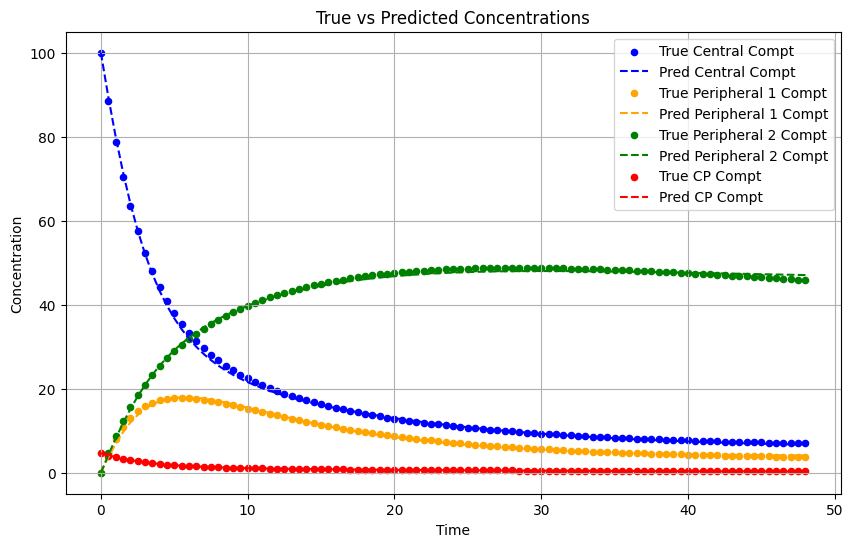

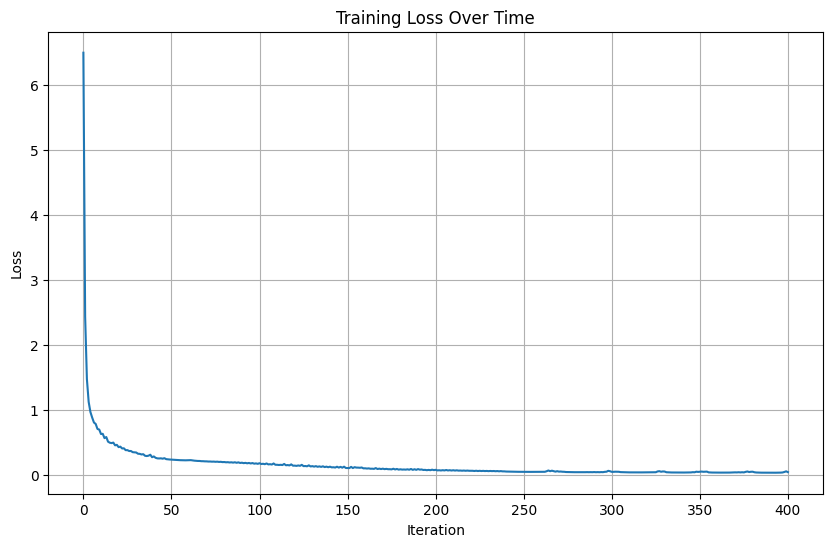

Saved GIF: training_animation.gif
Process time: 4.91 sec


In [174]:
# Solve using Improved Euler method
train_NODE(C_0, t, C_all, mu, sigma, improved_euler_solver, niters = 400, method='dopri8', gif=True)

Iter 0400 | Total Loss 0.030393


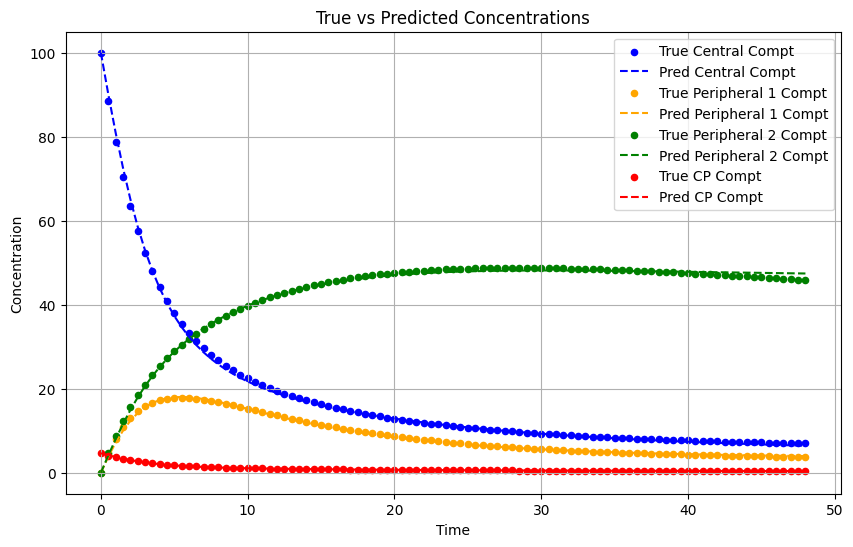

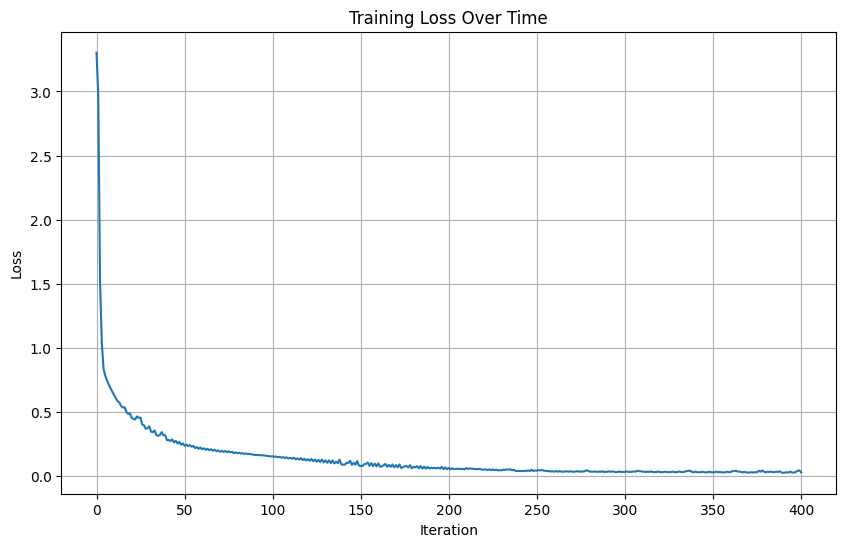

Saved GIF: training_animation.gif
Process time: 4.88 sec


In [175]:
# Solve using runge-Kutta 2th order method
train_NODE(C_0, t, C_all, mu, sigma, rk2_solver, niters = 400, method='dopri8', gif=True)

Iter 0400 | Total Loss 0.038115


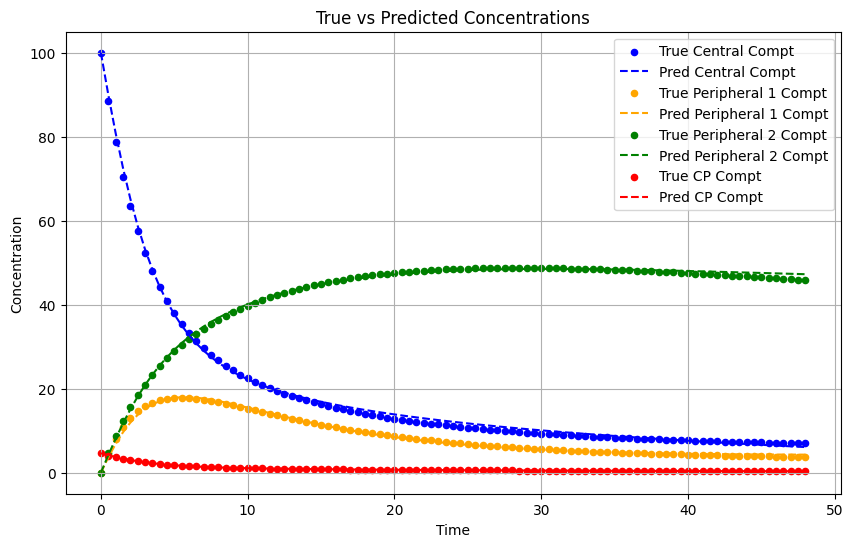

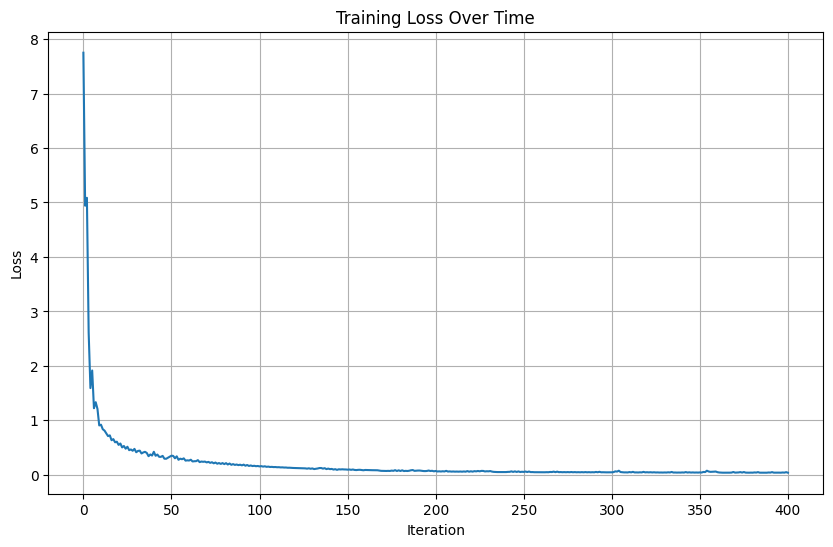

Saved GIF: training_animation.gif
Process time: 10.65 sec


In [176]:
# Solve using runge-Kutta 4th order method
train_NODE(C_0, t, C_all, mu, sigma, rk4_solver, niters = 400, method='dopri8', gif=True)